# Impor Libraries

In [6]:
# !pip uninstall gensim -y 
!pip install gensim #==3.8.3 #4.3.3
!pip install scikit-learn
!pip install numpy
!pip install torch==2.3.0 torchvision==0.18.0 torchaudio==2.3.0 --index-url https://download.pytorch.org/whl/cu121
# !pip uninstall tensorflow -y
!pip install tensorflow==2.17.0
!pip install matplotlib

Looking in indexes: https://download.pytorch.org/whl/cu121
Looking in indexes: https://download.pytorch.org/whl/cu121


In [11]:
import sys
import os
sys.path.insert(0, os.path.abspath("../.."))
# Reload modulos automaticamente
%load_ext autoreload
%autoreload 2
import os
from gensim.models import Word2Vec
# from utils import 
import numpy as np
import os
from collections import Counter

from BenchmarckASRelationships.bgp2vec.bgp2vec import BGP2VEC
from gensim.models import Word2Vec


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
TOR_LABELS_DICT = {'P2P':0, 'C2P': 1,'P2C': 2}
TOR_CSV_LABELS_DICT = {'P2P':0,'P2C': -1}

# PATH = "/home/valentina/Desktop/GIT/BenchmarckASRelationships/"
class_names = ['P2P', 'C2P', 'P2C']
# DATA = 'data/'

# MODELS_PATH = PATH +"bgp2vec/bgp2vec.word2vec"

# Dataset entrenamiento RNA para relaciones entre AS
MODEL_NAME = 'bgp2vec'

BINARYCLASS = False
# MAX_NUM_ROUTES = 1000000
# CANTID = '1m'
# MES = 'febrero'
# nombre_archivo = PATH + DATA + "sanitized_rib_febrero_2024.txt"

MAX_NUM_ROUTES = 1000000
MES = "marzo"
PATH = f"/media/vale/KINGSTON/TESIS/"
DATA = "data_2026/"
nombre_archivo = PATH + DATA + "rib_20260301_0000_to_20260302_0000.txt"

MODELS_PATH = PATH + DATA+"bgp2vec/bgp2vec.word2vec"


# Import BGP Routes

In [9]:

bgp_routes = [] 

with open(nombre_archivo, 'r') as archivo:
    for i,linea in enumerate(archivo):
        if i > MAX_NUM_ROUTES:
            break
        numeros = linea.strip().split('|')
        # numeros_enteros = list(map(int, numeros))
        bgp_routes.append(numeros)
        # bgp_routes.append(numeros_enteros)

bgp_routes = bgp_routes[1:]  # FIXME> arreglar esta a la firuflai

print("[RUTAS BGP]:",bgp_routes[:10])
print("[CANTIDAD PATHS]",len(bgp_routes))

[RUTAS BGP]: [['6939', '38040', '38040', '38040', '38040', '23969'], ['6939', '4651', '4651', '23969'], ['6939', '4651', '4651', '23969', '23969'], ['6939', '4651', '4651', '23969', '23974'], ['6939', '38040', '23969'], ['6939', '38040', '38040', '38040', '38040', '23969', '23969'], ['6939', '38040', '23969', '23969'], ['6939', '4788', '4788'], ['6939', '38040', '23969', '23974'], ['6939', '4651', '4651', '23969', '56120']]
[CANTIDAD PATHS] 1000000


## Crear Emberddings

In [10]:
import gensim
print(gensim.__version__)


4.4.0


In [17]:
test_limit = 27000000 #cantidad paths/horaciones
mode = None# 'test' # par limitar cantidad de paths/oraciones
epochs = 1
debug = True

# Crea embeddings de ASN con  BGP2VEC y lo guarda en "bgp2vec/bgp2vec.word2vec"
bgp2vec = BGP2VEC(model_path = MODELS_PATH ,
                  bgp_routes=bgp_routes,
                  rewrite=True, 
                  test_limit= test_limit, 
                  mode = mode, 
                  epochs = epochs)

print("[MODELO]",bgp2vec.model)
print("[NUMERO ASN REPETIDOS Y TODO]",bgp2vec.model.corpus_total_words)

[MODELO] Word2Vec<vocab=50112, vector_size=32, alpha=0.025>
[NUMERO ASN REPETIDOS Y TODO] 4760592


In [ ]:
ls  /media/vale/KINGSTON/TESIS/data_2026/bgp2vec/b

ls: no se puede acceder a '/media/vale/KINGSTON/TESIS/data_2026/bgp2vec/bgp2vec.word2vec': No existe el archivo o el directorio


## Importar Embeddings AS

In [20]:
MODELS_PATH

'/media/vale/KINGSTON/TESIS/data_2026/bgp2vec/bgp2vec.word2vec'

In [18]:
# Importar embeddings preentrenado de los ASN  con BGP2VEC
BGP2Vec_model = Word2Vec.load(MODELS_PATH)

# Obtener la matriz de embeddings
embeddings = BGP2Vec_model.wv.vectors
total_ASNs, embedding_vecor_length = embeddings.shape


print(f"[TOTAL ASN]: {total_ASNs}" )
print(f"[EMBEDDINGS LEN]: {embedding_vecor_length}")
print(f"[EMBEDDINGS] {embeddings}")

[TOTAL ASN]: 50112
[EMBEDDINGS LEN]: 32
[EMBEDDINGS] [[ 1.34684101e-01  7.93647915e-02 -1.23682939e-01 ... -1.94322252e+00
  -5.46288848e-01  5.13052270e-02]
 [ 4.44201112e-01  1.59391627e-01 -1.38823509e+00 ... -7.41793871e-01
   7.77487993e-01 -6.95211291e-01]
 [ 6.98942602e-01 -5.25366247e-01  9.00151506e-02 ... -6.74732625e-01
  -2.70078391e-01 -2.64313936e-01]
 ...
 [ 1.25640780e-02 -1.24262646e-02  1.05714165e-02 ...  1.53917521e-02
   4.21102718e-03 -6.11452758e-03]
 [-1.89998783e-02 -2.85013430e-02 -5.71632758e-03 ...  3.00588831e-03
  -2.77656242e-02  1.91122293e-03]
 [-1.67180821e-02 -2.63429359e-02 -1.44260637e-02 ... -8.80543888e-03
   2.41082124e-02  3.05872597e-02]]


In [6]:
# Mapeo ASN -> ID usado en los embeddings
asn_to_index = BGP2Vec_model.wv.key_to_index
print(f"[ASN TO INDEX]: {asn_to_index}")
print(f"[TAMANO]: {len(asn_to_index)}")

[ASN TO INDEX]: {'3356': 0, '1299': 1, '6939': 2, '174': 3, '2914': 4, '49544': 5, '199524': 6, '3320': 7, '19151': 8, '6453': 9, '3491': 10, '3257': 11, '6423': 12, '3701': 13, '6461': 14, '20055': 15, '6762': 16, '9002': 17, '32590': 18, '7018': 19, '2497': 20, '37271': 21, '30844': 22, '4637': 23, '12956': 24, '9498': 25, '20940': 26, '14537': 27, '12389': 28, '49666': 29, '8220': 30, '7500': 31, '266213': 32, '2500': 33, '11164': 34, '136557': 35, '140627': 36, '7594': 37, '137409': 38, '16552': 39, '4755': 40, '60068': 41, '13335': 42, '398465': 43, '6830': 44, '5511': 45, '1273': 46, '7713': 47, '13786': 48, '8529': 49, '2516': 50, '7195': 51, '45528': 52, '38880': 53, '52468': 54, '4766': 55, '6424': 56, '4775': 57, '24482': 58, '7922': 59, '4826': 60, '3216': 61, '13237': 62, '58511': 63, '8455': 64, '3170': 65, '13030': 66, '6667': 67, '18106': 68, '25091': 69, '23673': 70, '17660': 71, '63927': 72, '132337': 73, '20473': 74, '151326': 75, '24516': 76, '37497': 77, '1031': 78,

In [19]:
print(asn_to_index.get('1299'))
print(asn_to_index['1299'])
print(type(asn_to_index['1299']))


NameError: name 'asn_to_index' is not defined

# Importar ToR Dataset


In [8]:
# Cargar x_training y x_test
x_training = np.load(PATH + DATA + "x_training.npy").astype(int)
x_test = np.load(PATH + DATA + "x_test.npy").astype(int)


# Cargar y_training y y_test
y_training = np.load(PATH + DATA + "y_training.npy").astype(int)
y_test = np.load(PATH + DATA + "y_test.npy").astype(int)


print("x_training.shape:", x_training.shape)
print("y_training.shape:", y_training.shape)
print("x_test.shape:", x_test.shape)
print("y_test.shape:", y_test.shape)

print('x_training:',x_training)
print('y_training:',y_training)
print('x_test:',x_test)
print('y_test:',y_test)

x_training.shape: (805489, 2)
y_training.shape: (805489,)
x_test.shape: (201373, 2)
y_test.shape: (201373,)
x_training: [[ 35280 264906]
 [ 22355   3741]
 [ 14537  34224]
 ...
 [ 16552   4818]
 [ 21103   8359]
 [ 32934 397131]]
y_training: [0 0 0 ... 0 1 0]
x_test: [[ 39351  39493]
 [ 14361  15412]
 [ 61704  14537]
 ...
 [201225  12779]
 [136557  24203]
 [ 49100 206388]]
y_test: [0 0 0 ... 0 0 2]


los modelos de embeddings trabajan con índices, no con ASNs reales.

In [9]:
# ASN a índice -> x_training y x_test
x_training_mapped = []
y_training_filtered = []

# Recorrer par (asn, asn) y agregamos válidos
for (a, b), y in zip(x_training, y_training):
    a_index = asn_to_index.get(str(a), 0)
    b_index = asn_to_index.get(str(b), 0)

    # Ignorar si índice es 0 
    if a_index == 0 or b_index == 0 :
        continue
    
    x_training_mapped.append([a_index, b_index])
    y_training_filtered.append(y)

# Convertir listas a arrays de NumPy
x_training_mapped = np.array(x_training_mapped)
y_training_filtered = np.array(y_training_filtered)

# ---------------------------------------------------------------------------

x_test_mapped = []
y_test_filtered = []

for (a, b), y in zip(x_test, y_test):
    a_index = asn_to_index.get(str(a), 0)
    b_index = asn_to_index.get(str(b), 0)

    # Ignorar si índice es 0 
    if a_index == 0 or b_index == 0:
        continue
    
    x_test_mapped.append([a_index, b_index])
    y_test_filtered.append(y)

x_test_mapped = np.array(x_test_mapped)
y_test_filtered = np.array(y_test_filtered)

# Guardar los datos corregidos
np.save("x_training_mapped.npy", x_training_mapped)
np.save("y_training_filtered.npy", y_training_filtered)
np.save("x_test_mapped.npy", x_test_mapped)
np.save("y_test_filtered.npy", y_test_filtered)


## Modelo NN

In [10]:
from keras.layers import Conv1D, MaxPooling1D
from keras.models import Sequential
from keras.layers import Dense, Reshape, Flatten
# # from keras.layers import LSTM
from keras.layers import Embedding
# # from keras.preprocessing import sequence
# # from keras.callbacks import TensorBoard, ModelCheckpoint
from keras.utils import to_categorical
from keras.callbacks import ModelCheckpoint

2026-04-16 13:28:23.222874: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-16 13:28:23.334479: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-16 13:28:23.380746: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-16 13:28:23.396189: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-16 13:28:23.483872: I tensorflow/core/platform/cpu_feature_guar

In [11]:
print("[SHAPE EMDEDINGS]",embeddings.shape)

[SHAPE EMDEDINGS] (50112, 32)


In [12]:
# Configuración de la RNN BGP2VEC
experiment = None
num_classes = len(class_names)
embedding_trainable = False
input_length = 2  # longitud de la secuencia de entrada
embedding_vector_length = 32  # tamaño de los vectores de embedding
total_ASNs = embeddings.shape[0] #42865 # Tamaño del vocabulario


# Registro de parámetros del experimento si es aplicable
if experiment is not None:
    experiment.log_parameter("embedding_trainable", embedding_trainable)

# Definición del modelo
model = Sequential()
model.add(Embedding(total_ASNs, embedding_vector_length, input_length=input_length,
                    weights=[embeddings], trainable=embedding_trainable))  # Asegúrate de que 'embeddings' esté definida
model.add(Conv1D(filters=32, kernel_size=3, padding='same', activation='relu'))

model.add(Reshape((32, 2)))  # Cambia Reshape para reflejar las dimensiones correctas
#model.add(Reshape((model.output_shape[2], model.output_shape[1])))  # Cambia Reshape para reflejar las dimensiones correctas
model.add(MaxPooling1D(pool_size=2))
model.add(Conv1D(filters=32, kernel_size=3, padding='same', activation='relu'))
model.add(Reshape((32,16)))  # Cambia Reshape para reflejar las dimensiones correctas
#model.add(Reshape((model.output_shape[2], model.output_shape[1])))  # Cambia Reshape para reflejar las dimensiones correctas
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
model.add(Dense(100, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

/home/vale/Escritorio/GIT/BenchmarckASRelationships/env310/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [13]:
# Compilación del modelo
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Resumen del modelo
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     1,603,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,603,584 (6.12 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,603,584 (6.12 MB)

None


In [14]:
# # Convertir las clases a un one-hot vector
# y_training_vector = to_categorical(y_training, num_classes) 
# y_test_vector = to_categorical(y_test, num_classes)
# print("[Y TRAINING VECTOR]",y_training_vector)
# print("[X TRAINING]",x_training)


# Convertir las clases a un one-hot vector
y_training_vector = to_categorical(y_training_filtered, num_classes) 
y_test_vector = to_categorical(y_test_filtered, num_classes)
print("[Y TRAINING VECTOR]",y_training_vector)
print("[X TRAINING]",x_training)

[Y TRAINING VECTOR] [[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 ...
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 0. 0.]]
[X TRAINING] [[ 35280 264906]
 [ 22355   3741]
 [ 14537  34224]
 ...
 [ 16552   4818]
 [ 21103   8359]
 [ 32934 397131]]


In [15]:
# Verificar correcta conversión de las clases
print("[NUMERO DE CLASES]",num_classes)
print("[Y TRAINIG]:",len(y_training),y_training)
print('[UNIQUE Y TRAINING]',np.unique(y_training))  # valores únicos de las etiquetas en y_training
print('[UNIQUE Y TEST]',np.unique(y_test))      # valores únicos de las etiquetas en y_test

[NUMERO DE CLASES] 3
[Y TRAINIG]: 805489 [0 0 0 ... 0 1 0]
[UNIQUE Y TRAINING] [0 1 2]
[UNIQUE Y TEST] [0 1 2]


In [16]:
# Use class_weight to deal with unbalanced dataset
from sklearn.utils import class_weight

# class_weights = class_weight.compute_class_weight('balanced', list(range(num_classes)), y_training)
# print(class_weights)
class_weights = None

In [17]:
# Fit model
checkpointer_acc = ModelCheckpoint(monitor='val_acc', filepath= os.getcwd() + MODEL_NAME + '_acc.weights.h5',
                                    verbose=1, 
                                    save_best_only=True, 
                                    save_weights_only=True)

checkpointer_loss = ModelCheckpoint(filepath= os.getcwd() + MODEL_NAME + '_loss.weights.h5', 
                                    verbose=1, 
                                    save_best_only=True, 
                                    save_weights_only=True)

callbacks = [checkpointer_loss,checkpointer_acc] #tensorboard


In [29]:
print("[EXPERIMENTS]",x_training)

[EXPERIMENTS] [[ 35280 264906]
 [ 22355   3741]
 [ 14537  34224]
 ...
 [ 16552   4818]
 [ 21103   8359]
 [ 32934 397131]]


In [ ]:
import math
experiment = None
epochs = 10
batch_size = 64
steps_per_epoch = math.ceil(len(x_training_mapped)/batch_size)
val_batch_size = 64
validation_steps = math.ceil(len(x_test_mapped)/val_batch_size)



def generator(features, labels, batch_size):
    while True:
        for i in range(0, len(features), batch_size):
            batch_features = features[i:i + batch_size]
            batch_labels = labels[i:i + batch_size]
            
            yield np.array(batch_features), np.array(batch_labels)


def val_generator(features, labels, batch_size):
    while True:
        for i in range(0, len(features), batch_size):
            batch_features = features[i:i + batch_size]
            batch_labels = labels[i:i + batch_size]
            
            yield np.array(batch_features), np.array(batch_labels)







In [22]:
history = model.fit(
        x=generator(x_training_mapped, y_training_vector, batch_size),
        steps_per_epoch=steps_per_epoch,
        epochs=epochs,
        callbacks=callbacks,
        class_weight=class_weights,
        validation_data=val_generator(x_test_mapped, y_test_vector, val_batch_size),
        validation_steps=validation_steps
    )

Epoch 1/10
12572/12586 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8922 - loss: 0.2885
Epoch 1: val_loss improved from 0.30023 to 0.29261, saving model to /home/vale/Escritorio/GIT/BenchmarckASRelationships/bgp2vecbgp2vec_loss.weights.h5

Epoch 1: val_loss improved from 0.30023 to 0.29261, saving model to /home/vale/Escritorio/GIT/BenchmarckASRelationships/bgp2vecbgp2vec_loss.weights.h5


ValueError: ModelCheckpoint callback received monitor=val_acc, but Keras isn't able to automatically determine whether that metric should be maximized or minimized. Pass `mode='max'` in order to monitor based on the highest metric value, or pass `mode='min'` in order to use the lowest value.

In [ ]:
print(x_training_mapped.max(), x_test.max())  # Verifica el valor máximo de los índices
print(x_training_mapped.min(), x_test.min())  # Verifica que no haya valores negativos


42241 401307
1 1


### Plot History Accuracy

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


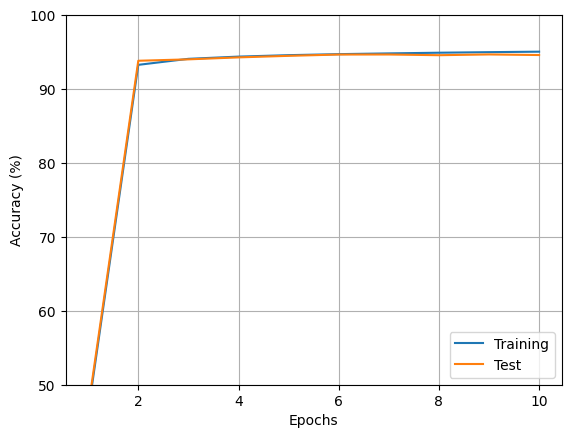

In [ ]:
import matplotlib.pyplot as plt
import pickle
%matplotlib inline

def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    y_smooth = np.convolve(y, box, mode='same')
    return y_smooth


with open(os.getcwd() + "/results/results_" + MODEL_NAME +  "_accuracy.pkl", 'wb') as output:
    pickle.dump(history.history, output, pickle.HIGHEST_PROTOCOL)
    if experiment is not None:
        experiment.log_asset(os.getcwd() + "/results/results_" + MODEL_NAME +  "_accuracy.pkl")
    
# list all data in history
print(history.history.keys())
x = np.asarray(range(1,epochs + 1))
# summarize history for accuracy
plt.figure()
plt.plot(x, smooth([y*100 for y in history.history['accuracy']],2))
# plt.plot(x, [y*100 for y in history_history['val_acc']])
plt.plot(x, smooth([y*100 for y in history.history['val_accuracy']],2))
plt.ylabel('Accuracy (%)')
plt.xlabel('Epochs')
plt.ylim(50,100) ###########################
plt.legend(['Training', 'Test'], loc='lower right')
plt.grid()
plt.savefig("results/acc_epochs", bbox_inches='tight')
plt.show()


### Final Evaluation of the Model

In [ ]:
test_scores = model.evaluate(x_test_mapped, y_test_vector, batch_size=val_batch_size, verbose=1)
print("Accuracy: %.2f%%" % (test_scores[1]*100))

1908/1908 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9453 - loss: 0.1595
Accuracy: 94.47%


In [ ]:
# y_test_prediction = model.predict_classes(x_test, batch_size=val_batch_size, verbose=1)
y_test_predictions_prob = model.predict(x_test_mapped, batch_size=val_batch_size, verbose=1)
# Obtener pradicciones de las clases
y_test_prediction = np.argmax(y_test_predictions_prob, axis=1)

1908/1908 ━━━━━━━━━━━━━━━━━━━━ 2s 830us/step


In [ ]:
# y_training_prediction = model.predict_classes(x_training, batch_size=val_batch_size, verbose=1)
y_training_predictions_prob = model.predict(x_training_mapped, batch_size=val_batch_size, verbose=1)
# Obtener las clases predichas
y_training_prediction = np.argmax(y_training_predictions_prob, axis=1)

7642/7642 ━━━━━━━━━━━━━━━━━━━━ 7s 863us/step


In [ ]:
y_test_vector

array([[0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       ...,
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.]])

In [ ]:
count = Counter(y_test_prediction)
print("[COUNTER] ", count)

[COUNTER]  Counter({0: 87811, 1: 17318, 2: 16982})


In [ ]:
from collections import Counter

# Contadores para correctos e incorrectos por clase (según etiqueta verdadera)
correctos = Counter()
incorrectos = Counter()

# Recorremos las etiquetas
for verdadero, predicho in zip(y_test_filtered, y_test_prediction):
    if verdadero == predicho:
        correctos[verdadero] += 1
    else:
        incorrectos[predicho] += 1

print("Correctos por clase:", dict(correctos))
print("Incorrectos por clase:", dict(incorrectos))


Correctos por clase: {2: 15230, 0: 84763, 1: 15366}
Incorrectos por clase: {0: 3048, 1: 1952, 2: 1752}


In [ ]:
# Guardamos los resultados en bgp2vec_results_tor.txt

with open(f"results/bgp2vec_results_tor_{CANTID}_{MES}.txt", "w") as f:
    # AS1 | AS2 | Predicción | Real
    for i in range(len(y_test_prediction)):
        f.write(f"{x_test_mapped[i][0]}|{x_test_mapped[i][1]}|{y_test_prediction[i]}|{y_test[i]} \n")

print("Archivo results/bgp2vec_results_tor_{CANTID}_{MES}.txt guardado correctamente.")

Archivo results/bgp2vec_results_tor_{CANTID}_{MES}.txt guardado correctamente.


### Plot and save a confusion matrix for results over the test set


In [ ]:
%matplotlib inline

import matplotlib
import pylab as pl
from sklearn.metrics import confusion_matrix
import itertools
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          fname='results/Confusion_matrix_bgp2vec',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
        plt.imshow([[100*j for j in i] for i in cm], interpolation='nearest', cmap=cmap)
        cbar = plt.colorbar()
        cbar.ax.set_yticklabels(['0%','20%','40%','60%','80%','100%'])
    else:
        print('Confusion matrix, without normalization')
        plt.imshow(cm, interpolation='nearest', cmap=cmap)
        plt.colorbar()
    
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.1f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        if normalize:
            plt.text(j, i, format(cm[i, j]*100, fmt) + '%',
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
        else:
            plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")    
        
    plt.tight_layout()
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig(fname, bbox_inches='tight')

Confusion matrix, without normalization
Normalized confusion matrix


/tmp/ipykernel_6564/3662359247.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.ax.set_yticklabels(['0%','20%','40%','60%','80%','100%'])


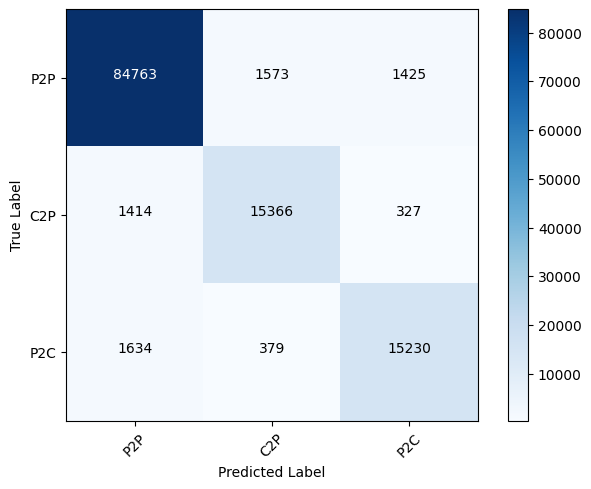

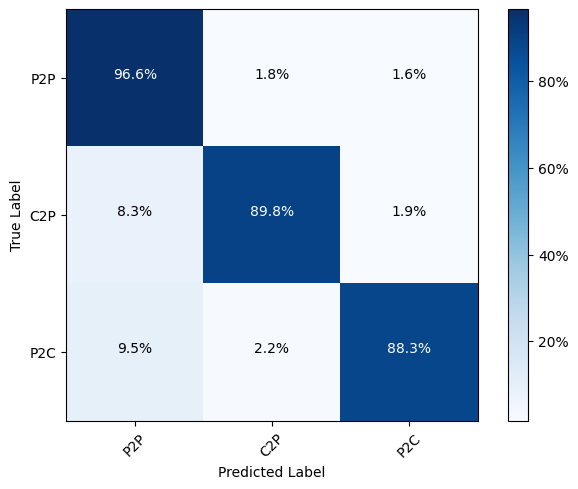

In [ ]:
# Compute confusion matrix
cnf_matrix = confusion_matrix(y_test_filtered, y_test_prediction)
np.set_printoptions(precision=2)

# Plot non-normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=class_names,
                      title='Confusion matrix, without normalization')

# Plot normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=class_names, normalize=True,
                      title='Normalized Confusion Msatrix')


plt.show()